In [1]:
# Importing All Necessary Libraries
# For Data Manipulation
import pandas as pd
import numpy as np

# For Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# To save model
import joblib

# For data preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# For performence measurement
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

# For machine Learning  
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
# Loading data 
df = pd.read_csv("../data/raw/Loan_Default.csv")

In [3]:
# To get an idea of data
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.head())
print(df.isnull().sum())

(148670, 34)
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')
ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        obje

In [4]:
# To see the distribution of output to check how many binary and how they are
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

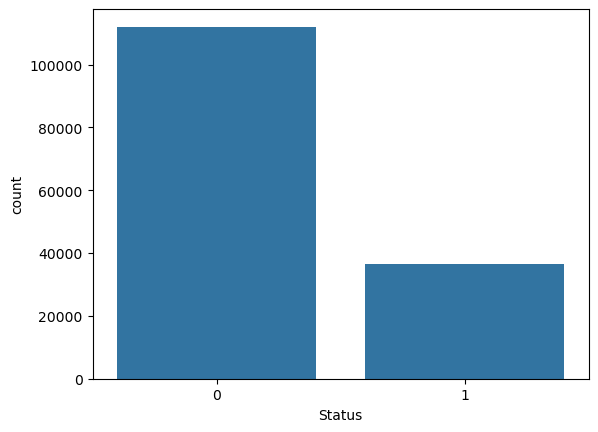

In [5]:
# Plotting in form of hisogram for better  
sns.countplot(x='Status', data=df)
plt.show()

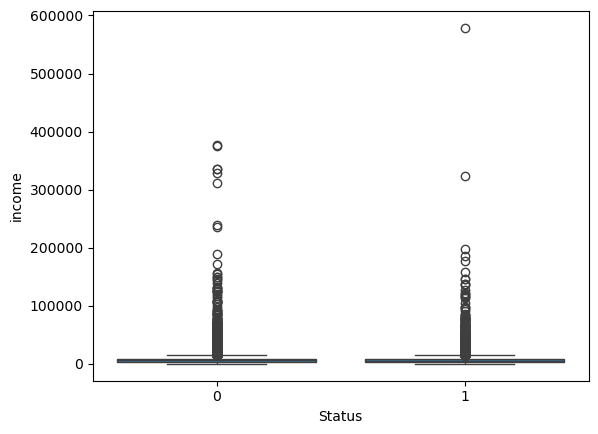

In [6]:
# Relationship between status and income 
sns.boxplot(x='Status', y='income', data=df)
plt.show()

In [7]:
# Since the above data is highly right sckewed, applying log transformation
df.loc[:,"income"] = np.log1p(df["income"])

In [8]:
# Distributing data 
y = df["Status"]
x = df.drop(columns=["Status", "Loan_ID", "credit_type_EQUI"], errors="ignore")

In [9]:
# Splitting data in test and train 
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

In [10]:
# Seterating rather storing numerical and categorical ddata in two different columns 
num_cols = x_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = x_train.select_dtypes(include=["object"]).columns

In [11]:
# Defining two pipeline one for numerical columns and other for categorical 
#Imputing missing values with median in numercal column 
# Imputing missing value with most frequent one in categorical 
num_pipeline = Pipeline([("imputerSWEP", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
cat_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

In [12]:
# Defining a complete preprocessor 
preprocessor = ColumnTransformer([("num", num_pipeline, num_cols),("cat", cat_pipeline, cat_cols)])

In [13]:
# Definig an dictionary of different models 
# We will compare different model 
models = {"LogisticRegression": (LogisticRegression(max_iter=1000),{"model__C": [0.1, 1, 10]}),
          "RandomForest": (RandomForestClassifier(random_state=42),{"model__n_estimators": [100, 200],"model__max_depth": [None, 5, 10]}),
          "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=42),{"model__n_estimators": [100, 200],"model__max_depth": [3, 5],"model__learning_rate": [0.05, 0.1]})}

In [14]:
# We are trying to find best model on the basis of auc roc score 
# We will use the Best model 
# The snippet will find the best model after this will 
best_auc = 0
best_model = None
best_name = ""
for name, (model, param_grid) in models.items():
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline([("preprocessor", preprocessor),("model", model)])
    
    grid_search = GridSearchCV(pipeline,param_grid,cv=3,scoring="roc_auc",n_jobs=-1)
    grid_search.fit(x_train, y_train)
    
    y_pred_proba = grid_search.best_estimator_.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"{name} Best Params: {grid_search.best_params_}")
    print(f"{name} Test AUC: {auc}")

    if auc > best_auc:
        best_auc = auc
        best_model = grid_search.best_estimator_
        best_name = name 


Training LogisticRegression...
LogisticRegression Best Params: {'model__C': 1}
LogisticRegression Test AUC: 0.8711062826473104

Training RandomForest...
RandomForest Best Params: {'model__max_depth': None, 'model__n_estimators': 100}
RandomForest Test AUC: 1.0

Training XGBoost...
XGBoost Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
XGBoost Test AUC: 0.9999822463045028


In [15]:
# Best model and best score store in best_name and best_auc respectively 
print("\nBest Model:", best_name)
print("Best AUC:", best_auc)

# Storing the best 
joblib.dump(best_model, f"best_model_{best_name}.pkl")

print("Best model saved successfully.")


Best Model: RandomForest
Best AUC: 1.0
Best model saved successfully.


In [16]:
# Finding and printing importance 
importances = best_model.named_steps["model"].feature_importances_

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                        Feature  Importance
4     num__Interest_rate_spread    0.260263
5          num__Upfront_charges    0.231601
3         num__rate_of_interest    0.167255
52        cat__credit_type_EQUI    0.145890
10                     num__LTV    0.031952
..                          ...         ...
70    cat__Security_Type_direct    0.000013
69  cat__Security_Type_Indriect    0.000011
45         cat__Secured_by_land    0.000008
39    cat__construction_type_mh    0.000006
1                     num__year    0.000000

[71 rows x 2 columns]


In [17]:
# Printing the test and train auc roc score
print("Train AUC:",
      roc_auc_score(y_train,
                    best_model.predict_proba(x_train)[:,1]))

print("Test AUC:",
      roc_auc_score(y_test,
                    best_model.predict_proba(x_test)[:,1]))

Train AUC: 1.0
Test AUC: 1.0
